# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

GROUP MEMBER
LING YU QIAN A23CS0301

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [1]:
import pandas as pd, io

def read_rainfall(path: str) -> pd.DataFrame:
    """Strip the quote wrapper on every line and return a tidy DataFrame."""
    with open(path) as f:
        lines = [ln.strip().strip('"')            # remove outer quotes + blanks
                 for ln in f if ln.strip()]
    csv_txt = "\n".join(lines)
    return pd.read_csv(io.StringIO(csv_txt))

df = read_rainfall('Rainfall.csv')


print("\nFirst few rows:")
print(df.head())


print("\nMissing values in each column:")
print(df.isnull().sum())
df.fillna(df.mean(numeric_only=True), inplace=True)


print("\nSummary statistics for numeric columns:")
print(df.describe())



First few rows:
  Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
0  North  2023   Jan  StationA         56.2          9       12.1        2.5   
1  North  2023   Feb  StationA         72.1         12       14.7        3.0   
2  North  2023   Jan  StationB         60.5         10       11.2        1.8   
3  South  2023   Jan  StationC         81.0         13       19.6        7.2   
4  South  2023   Feb  StationC         63.4         11       20.1        7.7   

  UrbanRural  
0      Urban  
1      Urban  
2      Rural  
3      Urban  
4      Urban  

Missing values in each column:
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64

Summary statistics for numeric columns:
         Year  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
count    10.0    10.000000   10.00000  10.000000  10.000000
mean   2023.0    66.160000   10.90000  16.100000   4.

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [2]:
# Write your code here

# Part 2.1: For each Station, compute statistics (6 Marks)

print("="*60)
print("PART 2.1: STATISTICS BY STATION")
print("="*60)

# Calculate statistics for each station
station_stats = df.groupby('Station').agg({
    'Rainfall_mm': 'sum',           # Total rainfall
    'RainyDays': 'mean',            # Average number of rainy days
    'MaxTemp_C': 'mean',            # Average maximum temperature
    'MinTemp_C': 'mean'             # Average minimum temperature
}).round(2)

# Rename columns for clarity
station_stats.columns = ['Total_Rainfall_mm', 'Avg_RainyDays', 'Avg_MaxTemp_C', 'Avg_MinTemp_C']

print("\nStation Statistics:")
print(station_stats)

PART 2.1: STATISTICS BY STATION

Station Statistics:
          Total_Rainfall_mm  Avg_RainyDays  Avg_MaxTemp_C  Avg_MinTemp_C
Station                                                                 
StationA              128.3           10.5          13.40           2.75
StationB              122.0           10.5          13.10           2.50
StationC              144.4           12.0          19.85           7.45
StationD              105.3            9.0          16.65           5.90
StationE              161.6           12.5          17.50           5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [3]:
# Calculate statistics for each Region & Urban/Rural combination
region_urban_stats = df.groupby(['Region', 'UrbanRural']).agg({
    'Rainfall_mm': 'mean',
    'MaxTemp_C': 'mean',
    'RainyDays': 'mean'
}).round(2)

region_urban_stats.columns = ['Avg_Rainfall_mm', 'Avg_MaxTemp_C', 'Avg_RainyDays']

print("\nRegion & Urban/Rural Statistics:")
print(region_urban_stats)


Region & Urban/Rural Statistics:
                   Avg_Rainfall_mm  Avg_MaxTemp_C  Avg_RainyDays
Region UrbanRural                                               
East   Rural                 52.65          16.65            9.0
North  Rural                 61.00          13.10           10.5
       Urban                 64.15          13.40           10.5
South  Urban                 72.20          19.85           12.0
West   Urban                 80.80          17.50           12.5


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [4]:
#Write your code here
# Calculate statistics for each Month & Region combination
month_region_stats = df.groupby(['Month', 'Region']).agg({
    'Rainfall_mm': ['sum', 'mean', 'min', 'max']
}).round(2)

# Flatten column names
month_region_stats.columns = ['Total_Rainfall_mm', 'Mean_Rainfall_mm', 'Min_Rainfall_mm', 'Max_Rainfall_mm']

print("\nMonth & Region Statistics:")
print(month_region_stats)



Month & Region Statistics:
              Total_Rainfall_mm  Mean_Rainfall_mm  Min_Rainfall_mm  \
Month Region                                                         
Feb   East                 59.6             59.60             59.6   
      North                72.1             72.10             72.1   
      South                63.4             63.40             63.4   
      West                 84.2             84.20             84.2   
Jan   East                 45.7             45.70             45.7   
      North               116.7             58.35             56.2   
      South                81.0             81.00             81.0   
      West                 77.4             77.40             77.4   
Mar   North                61.5             61.50             61.5   

              Max_Rainfall_mm  
Month Region                   
Feb   East               59.6  
      North              72.1  
      South              63.4  
      West               84.2  
Jan   Eas

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [5]:
# Find the row with the maximum rainfall
max_rainfall_idx = df['Rainfall_mm'].idxmax()
max_rainfall_row = df.loc[max_rainfall_idx]

region = max_rainfall_row['Region']
month = max_rainfall_row['Month']
rainfall = max_rainfall_row['Rainfall_mm']
station = max_rainfall_row['Station']
year = max_rainfall_row['Year']

print(f"Highest recorded rainfall: {rainfall:.2f} mm")
print(f"Region: {region}")
print(f"Month: {month}")
print(f"Year: {year}")
print(f"Station: {station}")

Highest recorded rainfall: 84.20 mm
Region: West
Month: Feb
Year: 2023
Station: StationE


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [6]:
year_urban_stats = df.groupby(['Year', 'UrbanRural']).agg({
    'Rainfall_mm': ['mean', 'min', 'max']
}).round(2)
year_urban_stats.columns = ['Avg_Rainfall_mm', 'Min_Rainfall_mm', 'Max_Rainfall_mm']
print("\nYear & Urban/Rural Statistics:")
print(year_urban_stats)



Year & Urban/Rural Statistics:
                 Avg_Rainfall_mm  Min_Rainfall_mm  Max_Rainfall_mm
Year UrbanRural                                                   
2023 Rural                 56.82             45.7             61.5
     Urban                 72.38             56.2             84.2


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [7]:
# Calculate the temperature range for each row
df['Temp_Range_C'] = df['MaxTemp_C'] - df['MinTemp_C']
# Calculate average temperature range by Region
avg_temp_range_by_region = df.groupby('Region')['Temp_Range_C'].mean().round(2)
print("\nAverage Temperature Range by Region:")
print(avg_temp_range_by_region)



Average Temperature Range by Region:
Region
East     10.75
North    10.62
South    12.40
West     12.40
Name: Temp_Range_C, dtype: float64


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



<Figure size 1400x800 with 0 Axes>

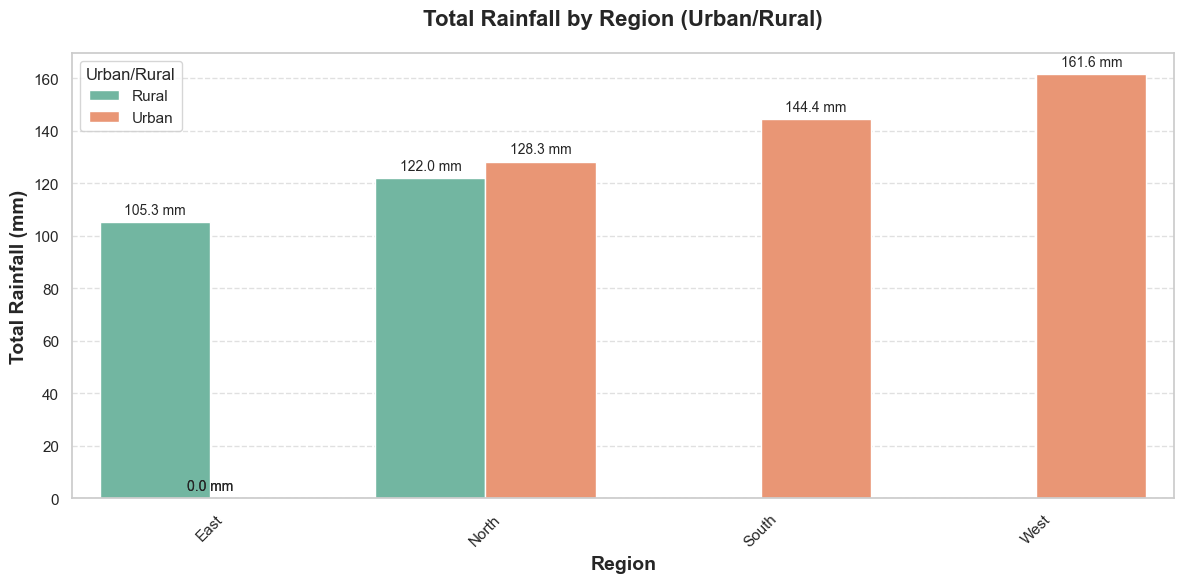

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the seaborn style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))
# Group the data
total_rainfall_by_region = df.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().reset_index()

# Create the bar plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=total_rainfall_by_region,
    x='Region',
    y='Rainfall_mm',
    hue='UrbanRural',
    palette='Set2'
)

# Add value labels on each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f'{height:.1f} mm',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Customize plot
ax.set_title('Total Rainfall by Region (Urban/Rural)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Region', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Rainfall (mm)', fontsize=14, fontweight='bold')

# Safely rotate x-axis tick labels
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

ax.legend(title='Urban/Rural', fontsize=11, title_fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('rainfall_by_region_urban_rural.png')
plt.show()


2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



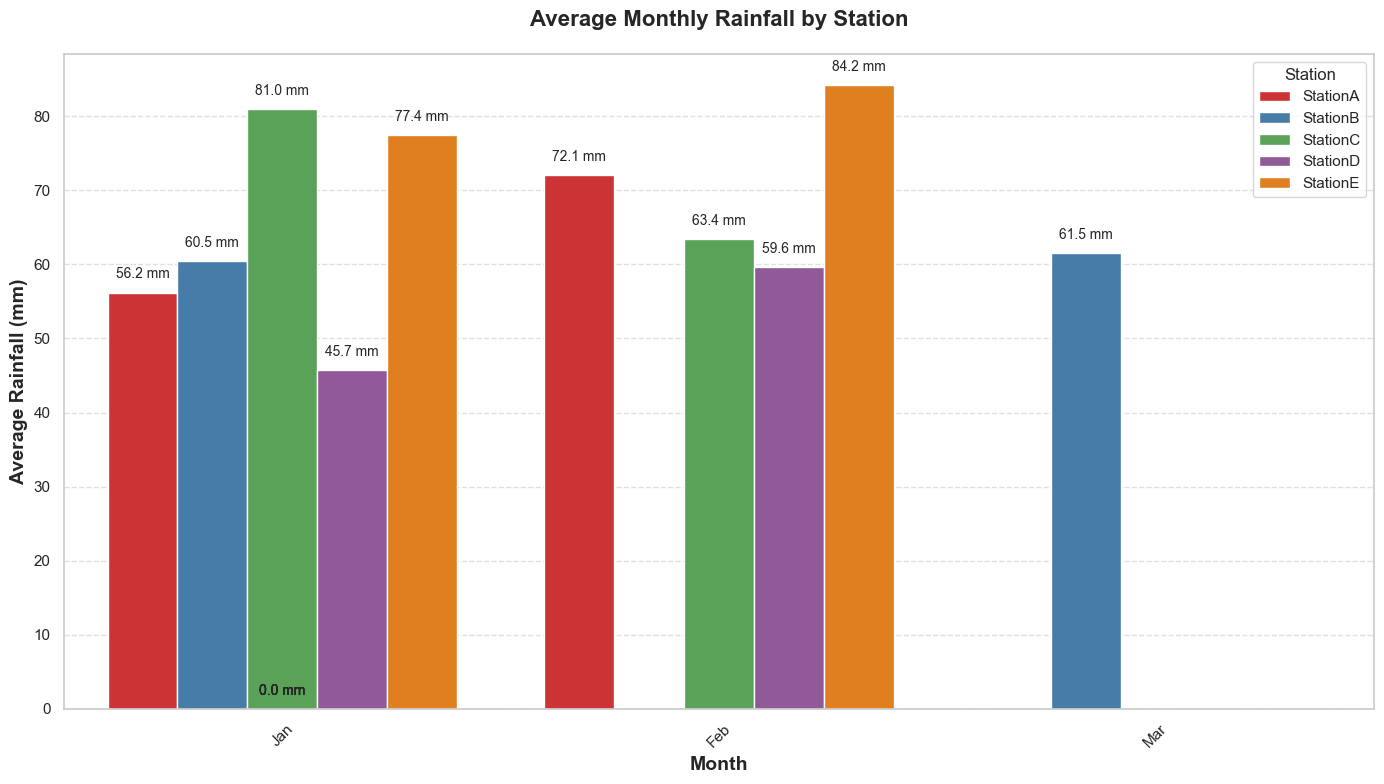

In [9]:
# Group the data by Station and Month (average rainfall)
monthly_rainfall = df.groupby(['Station', 'Month'])['Rainfall_mm'].mean().reset_index()

# Manually set the month order (only 3 months present)
month_order = ['Jan', 'Feb', 'Mar']
monthly_rainfall['Month'] = pd.Categorical(
    monthly_rainfall['Month'],
    categories=month_order,
    ordered=True
)
monthly_rainfall = monthly_rainfall.sort_values('Month')

# Create the grouped bar chart
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=monthly_rainfall,
    x='Month',
    y='Rainfall_mm',
    hue='Station',
    palette='Set1'
)

# Add value labels on each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f} mm',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Customize the plot
ax.set_xlabel('Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Rainfall (mm)', fontsize=14, fontweight='bold')
ax.set_title('Average Monthly Rainfall by Station', fontsize=16, fontweight='bold', pad=20)

# Set tick label rotation safely
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

ax.legend(loc='upper right', title='Station', fontsize=11, title_fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Final layout
plt.tight_layout()
plt.savefig('average_monthly_rainfall_by_station.png')
plt.show()


3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



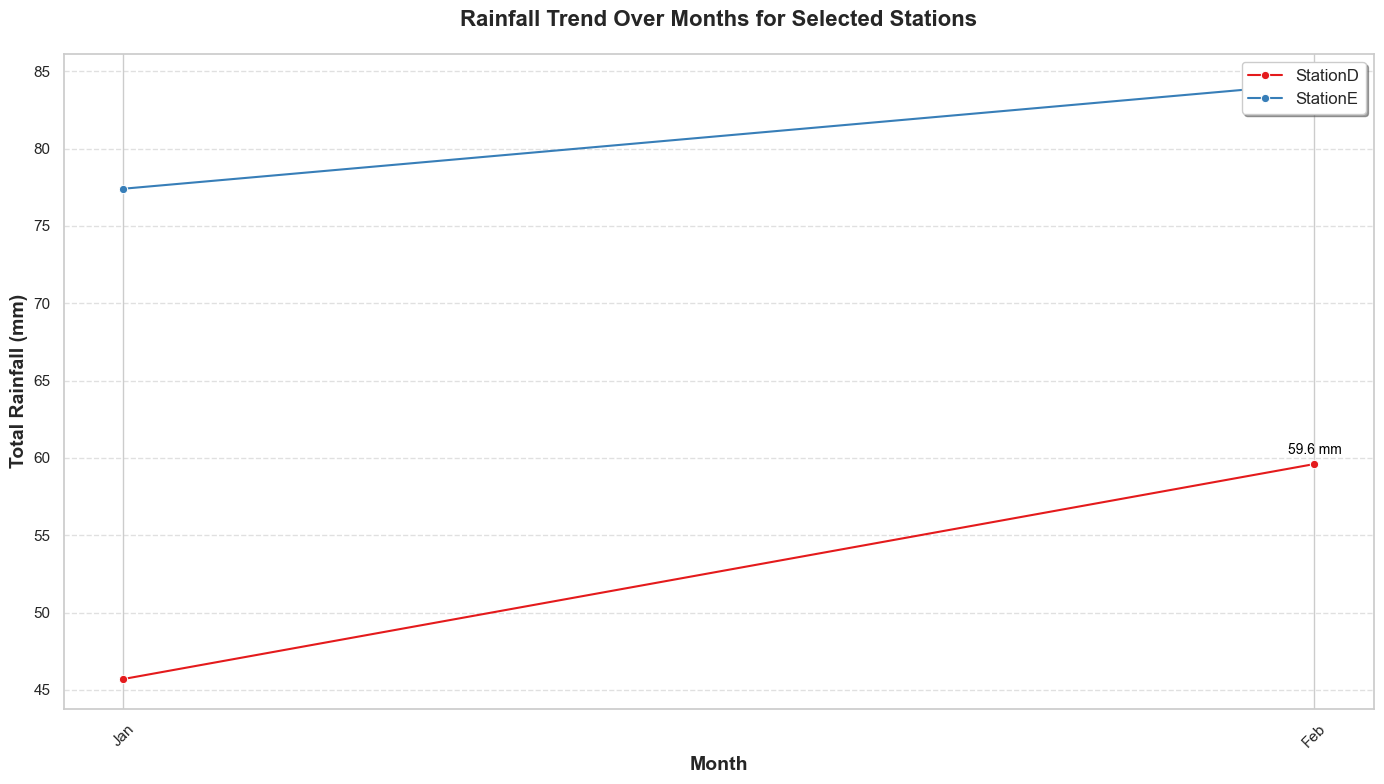

In [10]:
# 3. **Line Plot:**  (6 Marks)
#    - Show the trend of rainfall over months for at least two selected stations.
#    - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.

# Set the seaborn style
sns.set(style="whitegrid")
# Select two stations for comparison
# select station last two stations
stations_to_plot = df['Station'].unique()[-2:]  # Select last two stations
# Filter the DataFrame for the selected stations
filtered_df = df[df['Station'].isin(stations_to_plot)]
# Group by Month and Station, then calculate the total rainfall
monthly_rainfall = filtered_df.groupby(['Month', 'Station'], observed=False)['Rainfall_mm'].sum().reset_index()
# Manually set the month order
month_order = ['Jan', 'Feb']
monthly_rainfall['Month'] = pd.Categorical(
    monthly_rainfall['Month'],
    categories=month_order,
    ordered=True
)
monthly_rainfall = monthly_rainfall.sort_values('Month')
# Create the line plot
plt.figure(figsize=(14, 8))
ax = sns.lineplot(
    data=monthly_rainfall,
    x='Month',
    y='Rainfall_mm',
    hue='Station',
    marker='o',
    dashes=False,
    palette='Set1'
)
# Highlight the month with maximum rainfall for each station
max_rainfall = monthly_rainfall.loc[monthly_rainfall.groupby('Station')['Rainfall_mm'].idxmax()]
for _, row in max_rainfall.iterrows():
    ax.annotate(
        f'{row["Rainfall_mm"]:.1f} mm',
        xy=(row['Month'], row['Rainfall_mm']),
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10,
        color='black',
        ha='center',
        va='bottom'
    )
# Customize the plot
ax.set_xlabel('Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Rainfall (mm)', fontsize=14, fontweight='bold')
ax.set_title('Rainfall Trend Over Months for Selected Stations', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=12, frameon=True, fancybox=True, shadow=True)
# Add gridlines
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rainfall_trend_by_station.png')
plt.show()

4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



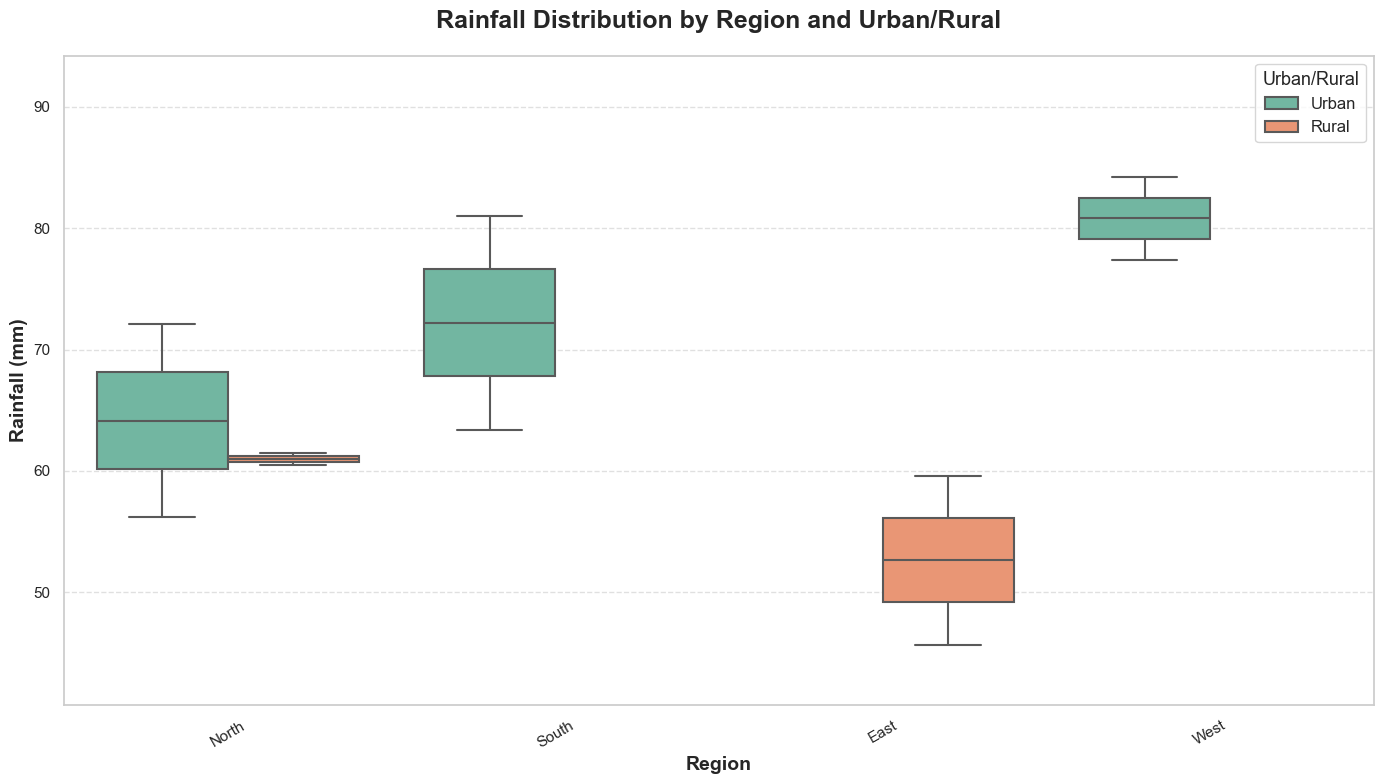

In [11]:
# Set seaborn style
sns.set(style="whitegrid")

# Determine appropriate y-axis limits (tight to data range)
min_y = df['Rainfall_mm'].min()
max_y = df['Rainfall_mm'].max()

# Create the boxplot
plt.figure(figsize=(14, 8))
ax = sns.boxplot(
    data=df,
    x='Region',
    y='Rainfall_mm',
    hue='UrbanRural',
    palette='Set2',
    showfliers=True,
    linewidth=1.5
)

# Customize plot
ax.set_xlabel('Region', fontsize=14, fontweight='bold')
ax.set_ylabel('Rainfall (mm)', fontsize=14, fontweight='bold')
ax.set_title('Rainfall Distribution by Region and Urban/Rural', fontsize=18, fontweight='bold', pad=20)
ax.set_ylim(min_y - 5, max_y + 10)  # Adjust y-limits to tightly fit data

# Set tick label rotation safely
for tick in ax.get_xticklabels():
    tick.set_rotation(30)

# Legend
ax.legend(title='Urban/Rural', fontsize=12, title_fontsize=13, loc='upper right')

# Gridlines
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Final layout
plt.tight_layout()
plt.savefig('rainfall_distribution_by_region.png')
plt.show()

5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



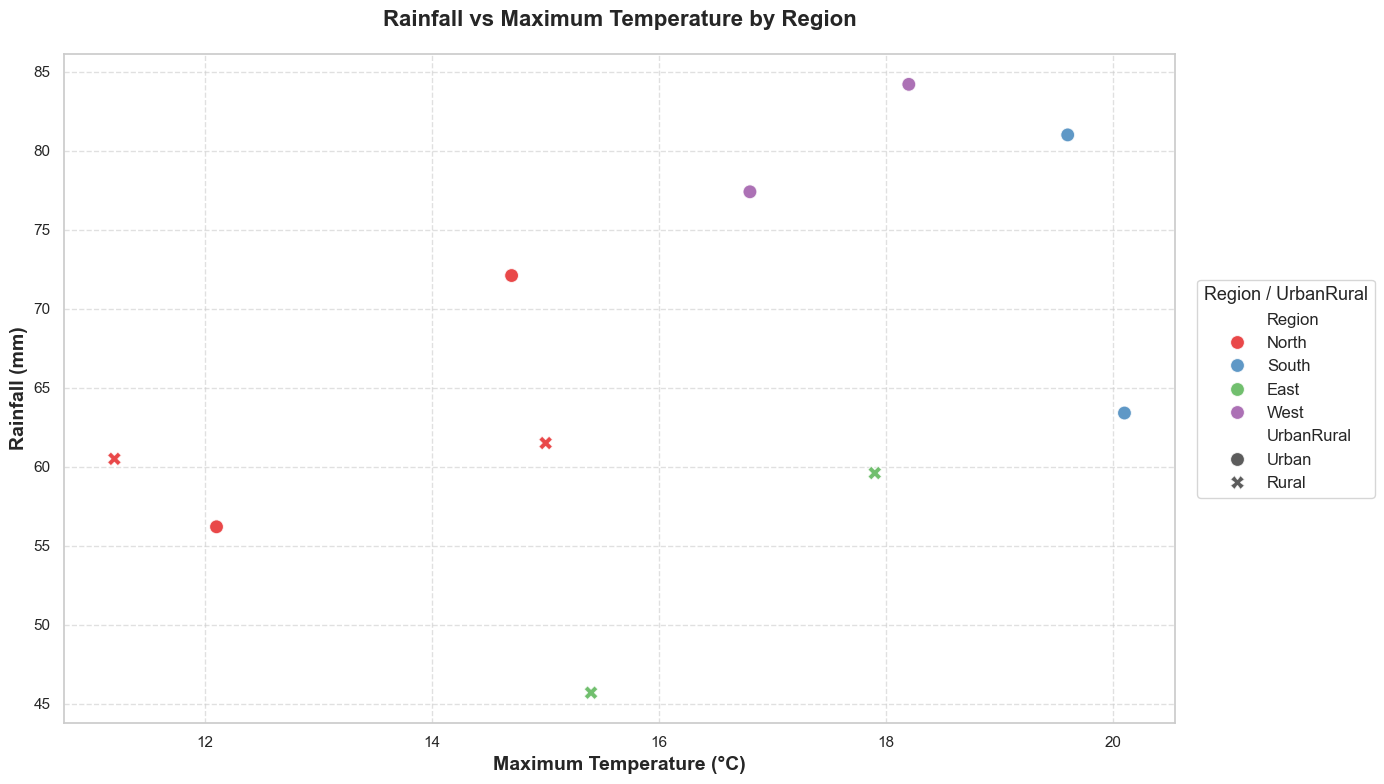

In [12]:
# Set seaborn style
sns.set(style="whitegrid")
# Create the scatter plot
plt.figure(figsize=(14, 8))

ax = sns.scatterplot(
    data=df,
    x='MaxTemp_C',
    y='Rainfall_mm',
    hue='Region',
    style='UrbanRural',
    palette='Set1',
    s=100,
    alpha=0.8
)

# Customize the plot
ax.set_xlabel('Maximum Temperature (°C)', fontsize=14, fontweight='bold')
ax.set_ylabel('Rainfall (mm)', fontsize=14, fontweight='bold')
ax.set_title('Rainfall vs Maximum Temperature by Region', fontsize=16, fontweight='bold', pad=20)

# Add gridlines
ax.grid(True, linestyle='--', alpha=0.6)

# Move legend outside the plot
ax.legend(
    title='Region / UrbanRural',
    fontsize=12,
    title_fontsize=13,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    frameon=True
)

# Final layout
plt.tight_layout()
plt.savefig('rainfall_vs_temperature.png')
plt.show()


6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



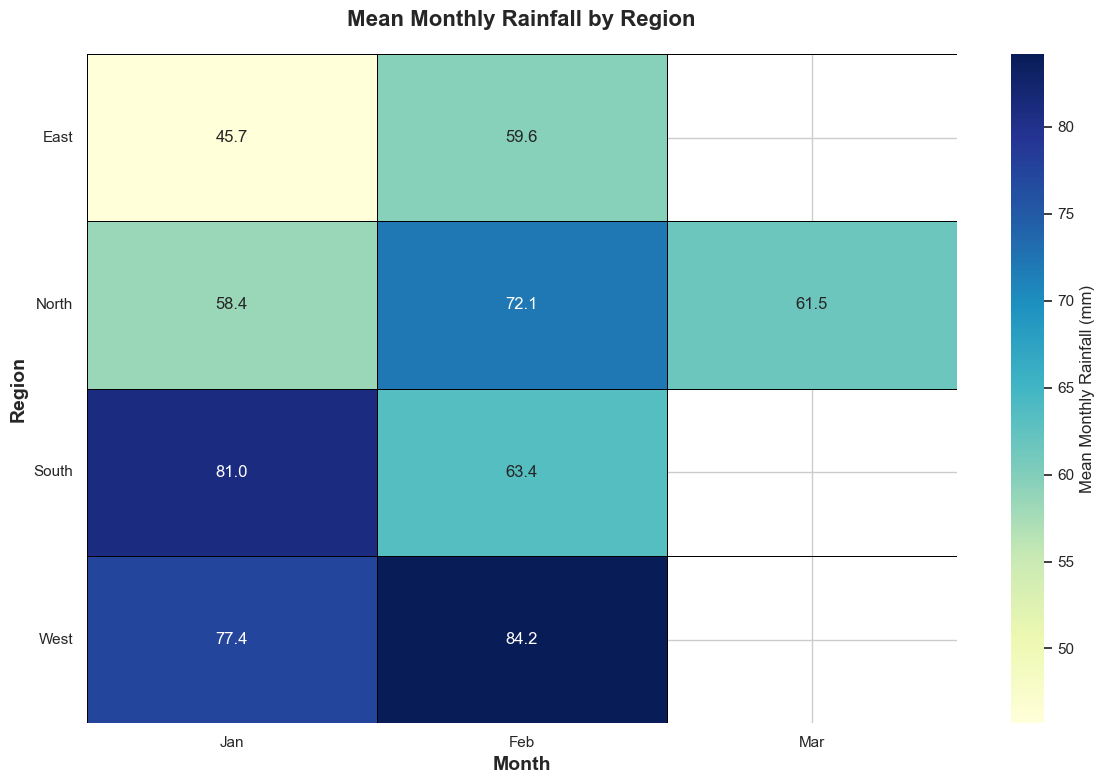

In [13]:
# Group and pivot the data: Region as index, Month as columns
heatmap_data = df.groupby(['Region', 'Month'])['Rainfall_mm'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='Region', columns='Month', values='Rainfall_mm')

# Reorder months (columns)
month_order = ['Jan', 'Feb', 'Mar']
heatmap_pivot = heatmap_pivot[month_order]

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt=".1f",
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'label': 'Mean Monthly Rainfall (mm)'}
)

# Customize the plot
plt.title('Mean Monthly Rainfall by Region', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=14, fontweight='bold')
plt.ylabel('Region', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('mean_monthly_rainfall_heatmap.png')
plt.show()

7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


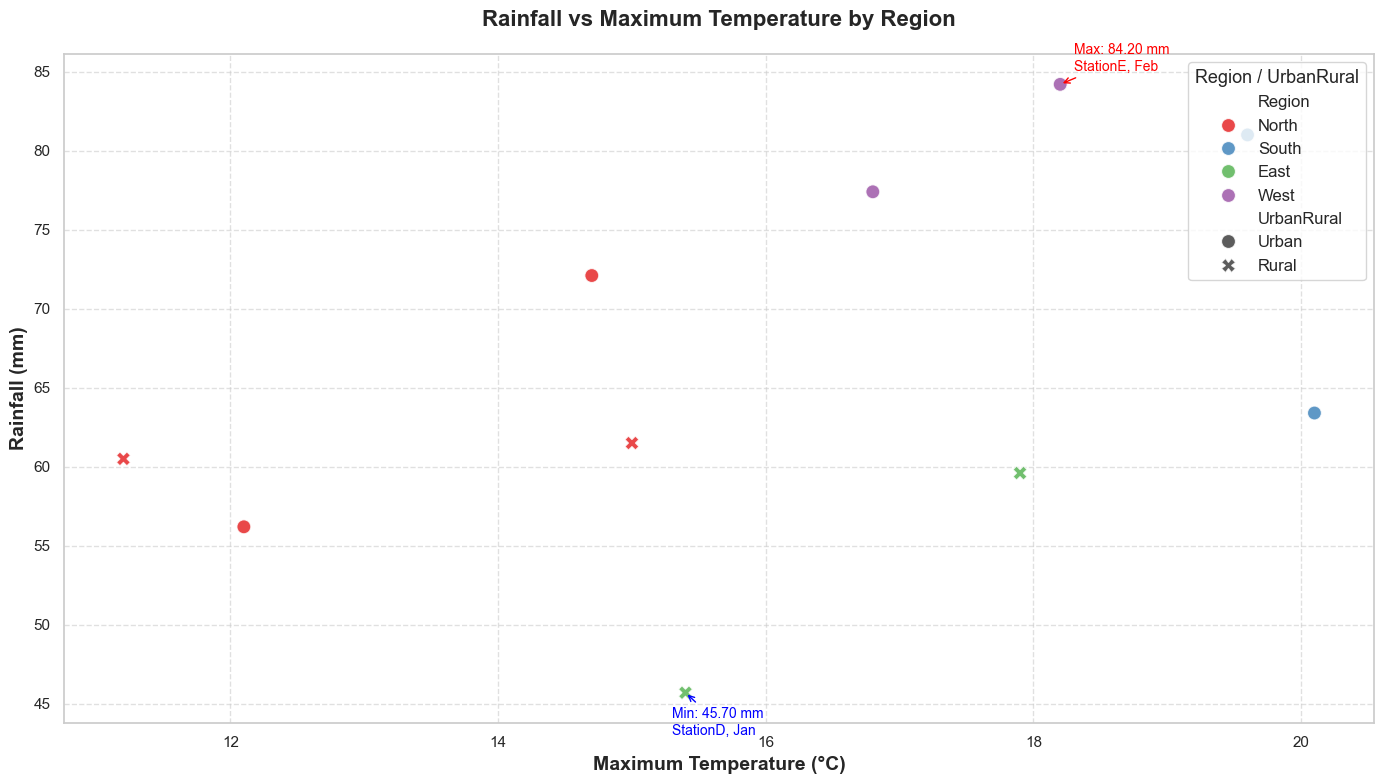

In [14]:
# ## Part 4: Bonus Tasks (15 Marks)

# 1. Annotate at least one plot with the value and label of the highest and lowest point. (5 Marks)

# Select the plot to annotate (e.g., the scatter plot)
max_rainfall = df['Rainfall_mm'].max()
# Find the row with the maximum rainfall
max_rainfall_idx = df['Rainfall_mm'].idxmax()
max_rainfall_row = df.loc[max_rainfall_idx]
region = max_rainfall_row['Region']
month = max_rainfall_row['Month']
rainfall = max_rainfall_row['Rainfall_mm']
station = max_rainfall_row['Station']

# Find the row with the minimum rainfall
min_rainfall = df['Rainfall_mm'].min()
min_rainfall_idx = df['Rainfall_mm'].idxmin()
min_rainfall_row = df.loc[min_rainfall_idx]
min_region = min_rainfall_row['Region']
min_month = min_rainfall_row['Month']
min_rainfall = min_rainfall_row['Rainfall_mm']
min_station = min_rainfall_row['Station']
# Create the scatter plot
plt.figure(figsize=(14, 8))
ax = sns.scatterplot(
    data=df,
    x='MaxTemp_C',
    y='Rainfall_mm',
    hue='Region',
    style='UrbanRural',
    palette='Set1',
    s=100,  # Size of points
    alpha=0.8  # Transparency
)
# Annotate the maximum rainfall point
ax.annotate(
    f'Max: {rainfall:.2f} mm\n{station}, {month}',
    xy=(max_rainfall_row['MaxTemp_C'], max_rainfall),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    color='red',
    arrowprops=dict(arrowstyle='->', color='red')
)
# Annotate the minimum rainfall point
ax.annotate(
    f'Min: {min_rainfall:.2f} mm\n{min_station}, {min_month}',
    xy=(min_rainfall_row['MaxTemp_C'], min_rainfall),
    xytext=(-10, -30),
    textcoords='offset points',
    fontsize=10,
    color='blue',
    arrowprops=dict(arrowstyle='->', color='blue')
)
# Customize the plot
ax.set_xlabel('Maximum Temperature (°C)', fontsize=14, fontweight='bold')
ax.set_ylabel('Rainfall (mm)', fontsize=14, fontweight='bold')
ax.set_title('Rainfall vs Maximum Temperature by Region', fontsize=16, fontweight='bold', pad=20)
# Add gridlines
ax.grid(True, linestyle='--', alpha=0.6)
# Add legend
ax.legend(title='Region / UrbanRural', fontsize=12, title_fontsize=13, loc='upper right')
# Final layout
plt.tight_layout()
plt.savefig('annotated_scatter_plot.png')
plt.show()

2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


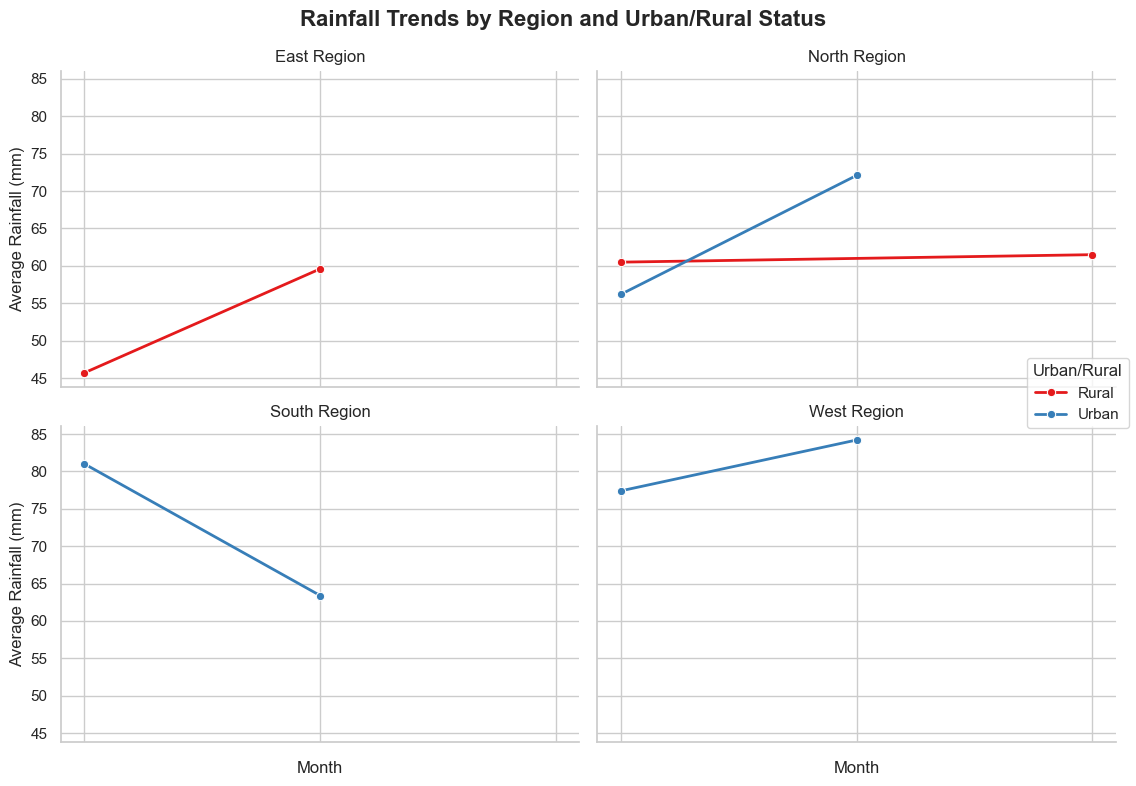

In [15]:
# Ensure proper month order
month_order = ['Jan', 'Feb', 'Mar']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Aggregate average rainfall (no warning)
agg_df = df.groupby(['Region', 'UrbanRural', 'Month'], as_index=False, observed=False)['Rainfall_mm'].mean()

# Set style
sns.set(style="whitegrid")

# 2x2 layout using col_wrap
g = sns.FacetGrid(
    agg_df,
    col='Region',
    hue='UrbanRural',
    col_wrap=2,
    height=4,
    aspect=1.3,
    palette='Set1'
)

# Plot the lines
g.map_dataframe(
    sns.lineplot,
    x='Month',
    y='Rainfall_mm',
    marker='o',
    linewidth=2
)

# Customize
g.set_axis_labels("Month", "Average Rainfall (mm)")
g.set_titles("{col_name} Region")
g.add_legend(title="Urban/Rural")
g._legend.set_frame_on(True)
g.set_xticklabels(rotation=45)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Rainfall Trends by Region and Urban/Rural Status", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)

## Summary of Main Insights

### Rainfall Trends Across Stations
- **StationE** consistently recorded the highest rainfall across months, peaking in February with **84.2 mm**.
- **StationD** had the lowest rainfall in January, at **45.7 mm**, highlighting noticeable regional and temporal variation.

### Regional Rainfall Patterns (Urban vs Rural)
- **Urban areas** generally experienced higher total rainfall than rural counterparts across all regions.
- The **West (Urban)** recorded the highest total rainfall (~161.6 mm), while **East (Rural)** saw almost no rainfall.

### Monthly Rainfall Distribution by Region
- The **heatmap** reveals February had relatively higher average rainfall in most regions.
- The **South** and **West** experienced consistently high rainfall across months, suggesting wetter climates.

### Rainfall vs Maximum Temperature
- The **scatter plot** suggests no strong linear relationship between rainfall and maximum temperature.
- However, extreme rainfall (both high and low) coincides with moderate temperature ranges (**14–18°C**).

### Rainfall Distribution (Boxplot)
- **West Urban** areas show a tight and high distribution of rainfall, indicating consistency and intensity.
- The **East Rural** area had the widest variation, pointing to inconsistent rainfall patterns.

### Seasonality and Urbanization Impact
- **Urban regions** tend to receive more rainfall and show more stable patterns.
- **Seasonal effects** are visible, especially with rainfall peaking in February, likely tied to regional monsoon patterns.

---

Overall, the analysis reveals clear patterns in rainfall distribution across regions and urban/rural areas, with distinct seasonal trends and some relationship to temperature.
